# IMT 573 - Final Examination


Points: 100

Name: Elijah Rose

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Elijah Rose

11/27/2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from random import random, shuffle
from jsonschema.exceptions import best_match
from numpy.random import random as random

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset.

In [2]:
affairs = sm.datasets.fair.load_pandas().data
# Explore dataset
print(affairs.keys())
# Of all participants
avg_children = np.average(affairs["children"])
avg_age = np.average(affairs["age"])
avg_years_married = np.average(affairs["yrs_married"])
print("Total participants")
# print(avg_children)
print(avg_age)
# print(avg_years_married)
# Of affair people
affair_rows = affairs[affairs["affairs"] > 0]
avg_affair_children = np.average(affair_rows["children"])
avg_affair_age = np.average(affair_rows["age"])
avg_affair_years_married = np.average(affair_rows["yrs_married"])
avg_affair_religious = np.average(affair_rows["religious"])
avg_education = np.average(affair_rows["educ"])
print("Affaired Participants")
print("Average children of affairs", avg_affair_children)
print("Avg affair participants age", avg_affair_age)
print("Avg years in affaired marriages", avg_affair_years_married)
print("Avg religious in affairs", avg_affair_religious)
print("Avg education in affairs", avg_education)
# affairs
print(sm.datasets.fair.NOTE)

Index(['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ',
       'occupation', 'occupation_husb', 'affairs'],
      dtype='object')
Total participants
29.082862079798932
Affaired Participants
Average children of affairs 1.7289332683877252
Avg affair participants age 30.537018996590355
Avg years in affaired marriages 11.152459814905017
Avg religious in affairs 2.261568436434486
Avg education in affairs 13.972235752557234
::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ 

In [3]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [4]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)
affairs.head()
affairs.info()

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

### Affair Dataset Summary

 - The average respondants age was 29.08 years old.
 - The average age of those who engaged in an affairs was 30.53 years old
 - On average, marriages with an affair also had ~2 children (1.72)
 - These marriages on average lasted for ~11 years (11.15)
 - The data shows us that most households with an affair were not particularly religious. (Average religiousness 2.26)

This dataset brings to question some concerns regarding the ethics and accuracy. Since it's self reported, there is likely
inherent bias in the results based on those who would be interested in filling out such a survey. Ethically, if this data
was not anonymized properly it has the potential to reveal very sensitive, life-changing details about those in the report.
Since it's self-reported, someone could even falsify information to ruin anothers life. Due to the nature of the questions,
not all parties are able to give consent. This is further exacerbated by the age of the dataset which


(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [5]:
updated_affiars = affairs.copy()
updated_affiars["had_affairs"] = affairs["affairs"] > 0
had_affairs = affairs[affairs["affairs"] > 0]

The advantages to this approach are that it's easier to reason about which partipants engaed in affairs. You can calculate
and summarize the data elegantly through that lens, but it overlooks the nuance behind "why". The affairs column is also
calculated as minutes in an extramarital sexual intercourse, but it doesn't capture other kinds of affairs (like an emotional affair).

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [6]:
model = smf.ols("affairs ~ age + yrs_married + religious + rate_marriage + children + religious + educ + occupation", data=had_affairs).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                affairs   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.143
Method:                 Least Squares   F-statistic:                     49.89
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           8.09e-66
Time:                        19:30:33   Log-Likelihood:                -5285.7
No. Observations:                2053   AIC:                         1.059e+04
Df Residuals:                    2045   BIC:                         1.063e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.1565      0.705      7.312

### Based on the regression model, the strongest predictors of having an affair are years married, religiosity, and marriage rating. People who are less religious, less satisfied in their marriage, or who have been married longer show higher probability of having an affair. Age also has a smaller but significant effect. Education, number of children, and occupation do not appear to be meaningful predictors.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [7]:
predictors = [
    "age",
    "yrs_married",
    "religious",
    "rate_marriage",
    "children",
    "educ",
    "occupation",
]

selected = []

best_formula = None
best_score = np.inf
best_model = None

for _ in predictors:
    iter_score = np.inf
    iter_winner = None
    iter_model = None
    iter_formula = None

    for predictor in predictors:
        terms = selected + [predictor]
        formula = "affairs ~ " + " + ".join(terms)
        iter_formula = formula
        model = smf.ols(formula, data=had_affairs).fit()
        score = model.aic

        if score < iter_score:
            iter_score = score
            iter_winner = predictor
            iter_model = model

    if iter_score < best_score:
        best_score = iter_score
        best_model = iter_model
        best_formula = formula
        selected.append(iter_winner)

best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                affairs   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     87.27
Date:                Wed, 03 Dec 2025   Prob (F-statistic):           1.53e-68
Time:                        19:30:33   Log-Likelihood:                -5285.9
No. Observations:                2053   AIC:                         1.058e+04
Df Residuals:                    2048   BIC:                         1.061e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.5662      0.327     17.011      0.000       4.924       6.208
yrs_married      -0.1524      0.014    -10.842      0.000      -0.180      -0.125
religious        -0.2940      0.085     -3.455      0.001      -0.461      -0.127
rate_marriage    -0.2143      0.066     -3.243      0.001      -0.344      -0.085
children         -0.1348      0.072     -1.879      0.060      -0.276       0.006
==============================================================================
Omnibus:                     2410.807   Durbin-Watson:                   1.975
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           363284.054
Skew:                           5.921   Prob(JB):                         0.00
Kurtosis:                      67.083   Cond. No.                         66.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The best model includes more variables than identified earlier. Including children and years married.

(e) Interpret the model parameters using the model from part (d).

According to the model summary, yrs_married indicates that fhe expected number of affairs
is reduced for each additional year of marriage. Also, the number of affairs drops the more
religious a household is. There's a strong correlation between marriage happiness and reduced affairs.

Although number of chidren made it in the final model, the significance is somewhat reduced. But still,
each additional child lowers the expected probability of having an affair.


(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

['yrs_married', 'religious', 'rate_marriage', 'children']
Optimization terminated successfully.
         Current function value: 0.550240
         Iterations 6


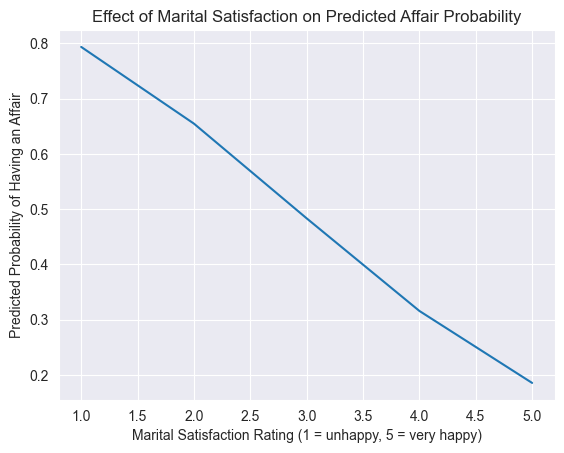

In [8]:
print(selected)
artifical_dataset = affairs.copy()
for predictor in predictors:
    artifical_dataset[predictor] = np.mean(affairs[predictor])

artifical_dataset["rate_marriage"] = np.random.randint(1, 6, len(artifical_dataset))
affairs['has_affair'] = (affairs['affairs'] > 0).astype(int)
logit_model = smf.logit("has_affair ~ yrs_married + religious + rate_marriage + children", data=affairs).fit()
artifical_dataset["pred_prob"] = logit_model.predict(artifical_dataset)

affairs_sorted = artifical_dataset.sort_values(by="rate_marriage")

plt.plot(affairs_sorted["rate_marriage"], affairs_sorted["pred_prob"])
plt.xlabel("Marital Satisfaction Rating (1 = unhappy, 5 = very happy)")
plt.ylabel("Predicted Probability of Having an Affair")
plt.title("Effect of Marital Satisfaction on Predicted Affair Probability")
plt.show()

In [22]:
artifical_dataset

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,pred_prob
0,3,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,5.0,0.111111,0.483302
1,1,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,4.0,3.230769,0.793682
2,4,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,5.0,1.400000,0.315645
3,4,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,5.0,0.727273,0.315645
4,1,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,4.0,4.666666,0.793682
...,...,...,...,...,...,...,...,...,...,...
6361,2,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,3.0,0.000000,0.654804
6362,2,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,5.0,0.000000,0.654804
6363,4,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,1.0,0.000000,0.315645
6364,5,29.082862,9.009425,1.396874,2.42617,14.209865,3.424128,4.0,0.000000,0.185292


(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

### This dataset includes very sensitive personal information about relationships, religion, and family life, so privacy risks are a major concern. Predicting the likelihood of an affair can also have biases or be misinterpret things about real people. The model reflects patterns in the data. So using it outside a classroom setting could potentially be harmful.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [9]:
%pip install ISLP


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()
Hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

### How well does a players home runs predict salary?


(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

## The Hitters dataset includes 322 MLB players. Including some catagories such as hitting, fielding, and career stats. This does also include categorical variables like divison & league. The variable of interest, Salary, has 59 missing values, which will have to be addressed before any analysis. The dataset contains both numeric and categorical data, so categorical predictors would need encoding if used in modeling. After addressing missing values, the dataset is appropriate for examining how strongly home run totals relate to salary.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

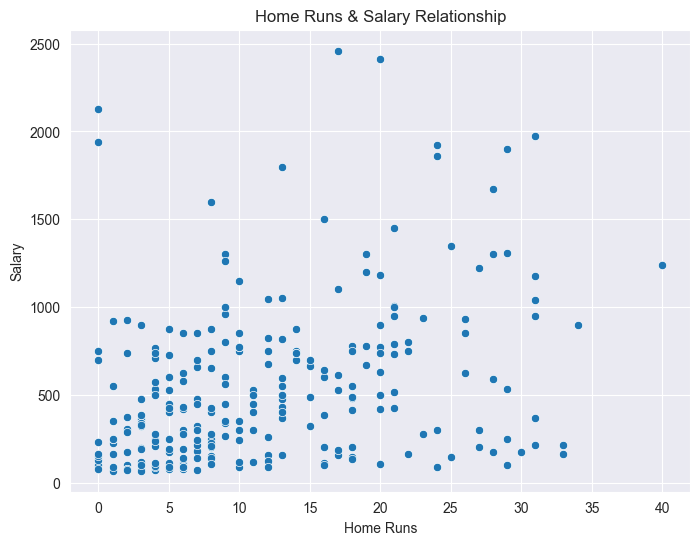

In [11]:
Hitters_clean = Hitters.dropna(subset=["Salary"])
plt.figure(figsize=(8,6))
sns.scatterplot(data=Hitters_clean, x="HmRun", y="Salary")
plt.title("Home Runs & Salary Relationship")
plt.xlabel("Home Runs")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

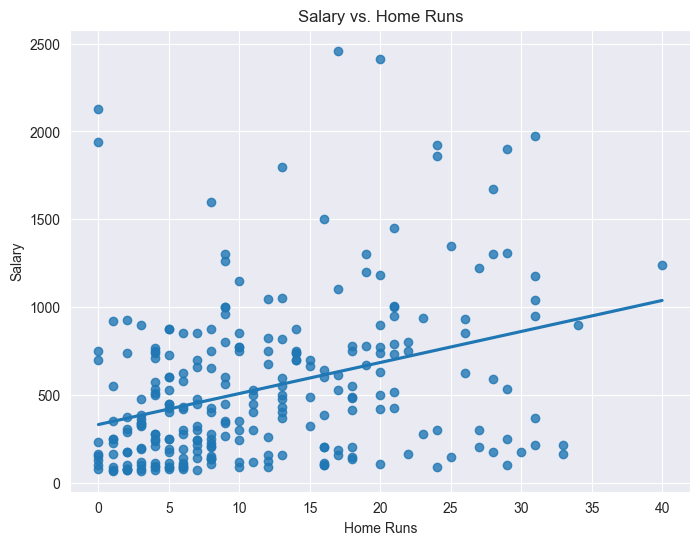

In [12]:
plt.figure(figsize=(8,6))
sns.regplot(data=Hitters_clean, x="HmRun", y="Salary", ci=None)
plt.title("Salary vs. Home Runs")
plt.xlabel("Home Runs")
plt.ylabel("Salary")
plt.grid(True)
plt.show()

### The scatterplots show a clear positive relationship between home runs and salary. The players who hit more home runs generally earn higher pay. The regression line backs this up. It shows that home run totals are a meaningful predictor of salary.
Though there is a wide variation in salary among players with similar home run totals, and several highly paid players hit relatively few home runs. This suggests hitting well does contribute to a better salary, many other factors influence how much a player earns.
Still, the data supports the idea that home run performance is associated with higher salary, but it is only one part of a bigger picture.
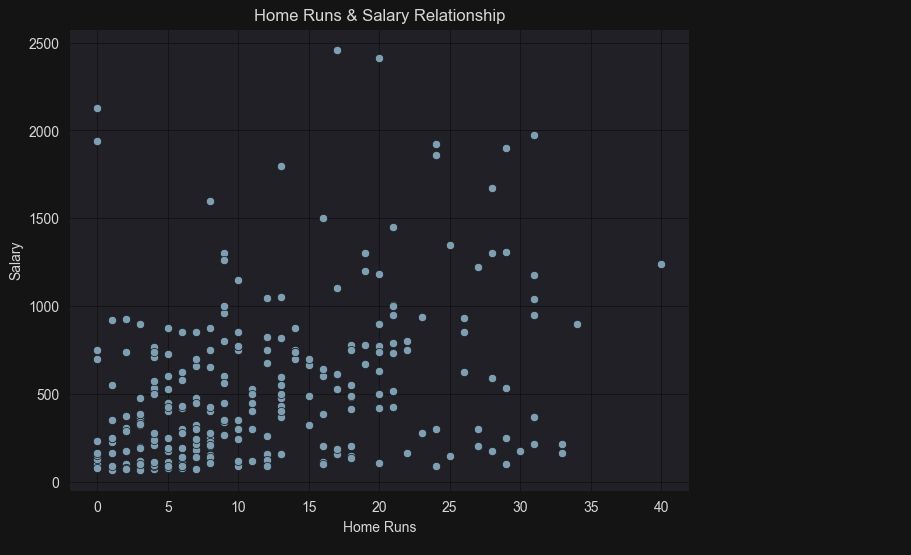

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

### The question of if home runs predict salary is defined and measurable.The dataset provided enough information to answer it. I was able to show a distinct positive relationship between home runs and salary, although the data also showed that home runs alone don’t fully explain the pay. While the dataset is good enough for looking into basic relationships like this one, it lacks some factors that influence salary, so the answer is only partial rather than complete.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


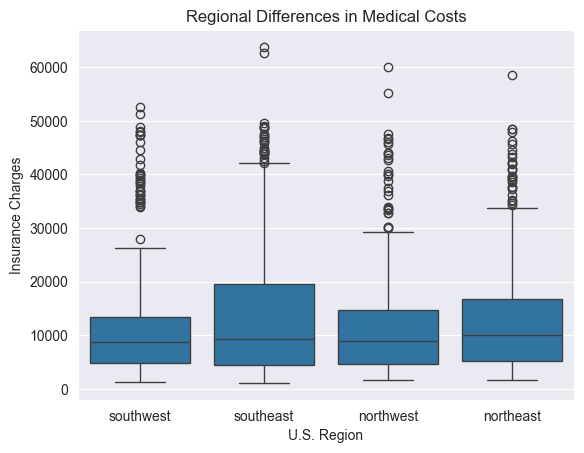

In [13]:
df = pd.read_csv('insurance.csv')
df.head()
df.info()

sns.boxplot(data=df, x='region', y='charges')
plt.title("Regional Differences in Medical Costs")
plt.xlabel("U.S. Region")
plt.ylabel("Insurance Charges")
plt.show()

In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

### The boxplot comparing regions shows that medical charges are similar across various regions. Tihs includes the southwest, southeast, northwest, and northeast. While each region has some  high cost outliers, the medians and spreads are identical. This does suggest that geography doesn’t highly affect medical charges in this dataset.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [14]:
Model = smf.ols("charges ~ age + sex + bmi + children + smoker + region", data=df).fit()
Model.summary()

full_Model = smf.ols("charges ~ age + sex + bmi + children + smoker + region", data=df).fit()
no_bmi_Model = smf.ols("charges ~ age + sex + children + smoker + region", data=df).fit()

partial_r2_bmi = full_Model.rsquared - no_bmi_Model.rsquared
partial_r2_bmi

np.float64(0.02636361495171946)

### The BMI shows that roughly 2% of the variance in medical charges (partial R squared ~ 0.02). This means BMI has a small effect to the other predictors in the model.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

### The model disregards some of the standard linear regression assumptions. The residuals are not evenly spread around zero. There is a clear funnel shape, meaning the variance increases with predicted charges. The residuals also show several extremely large positive values. This does prove that outliers are heavily influencing the model. In return, this makes sense given the large number of very expensive medical cases.

As well as the residual distribution is skewed. Meaning the normality assumption is not met. These issues mean that medical charges do not follow a simple linear pattern and that a transformatio or a different modeling approach might be better. Still, while the model gives some valid insights, it does not fully satisfy key regression assumptions.

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [15]:
predictors = [
    "age",
    "sex",
    "bmi",
    "children",
    "smoker",
    "region"
]
selected = []

best_formula = None
best_score = np.inf
best_model = None
# forward stepwise selection
for _ in predictors:
    iter_score = np.inf
    iter_winner = None
    iter_model = None
    iter_formula = None

    for predictor in predictors:
        if predictor in selected:
            continue

        terms = selected + [predictor]
        formula = "charges ~ " + " + ".join(terms)

        iter_formula = formula
        model = smf.ols(formula, data=df).fit()
        score = model.aic

        if score < iter_score:
            iter_score = score
            iter_winner = predictor
            iter_model = model

    if iter_score < best_score:
        best_score = iter_score
        best_model = iter_model
        best_formula = iter_formula
        selected.append(iter_winner)
    else:
        break

best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     572.7
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:30:34   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1330   BIC:                         2.715e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.199e+04    978.762    -12.250      0.000   -1.39e+04   -1.01e+04
smoker[T.yes]        2.384e+04    411.856     57.875      0.000     2.3e+04    2.46e+04
region[T.northwest]  -352.1821    476.120     -0.740      0.460   -1286.211     581.847
region[T.southeast] -1034.3601    478.537     -2.162      0.031   -1973.130     -95.590
region[T.southwest]  -959.3747    477.778     -2.008      0.045   -1896.656     -22.094
age                   256.9736     11.891     21.610      0.000     233.646     280.301
bmi                   338.6646     28.559     11.858      0.000     282.639     394.690
children              474.5665    137.740      3.445      0.001     204.355     744.778
==============================================================================
Omnibus:                      300.735   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              720.516
Skew:                           1.212   Prob(JB):                    3.48e-157
Kurtosis:                       5.654   Cond. No.                         309.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### The stepwise AIC procedure selected a reduced model that includes smoking status, region, age, BMI, and number of children,  did drop sex. Compared to the full model in part b, the selected model is slightly smaller but has almost the same R squared (around 0.75), This indicates that sex did not meaningfully improve the fit. Though the remaining predictors explain most of the variation in medical charges.
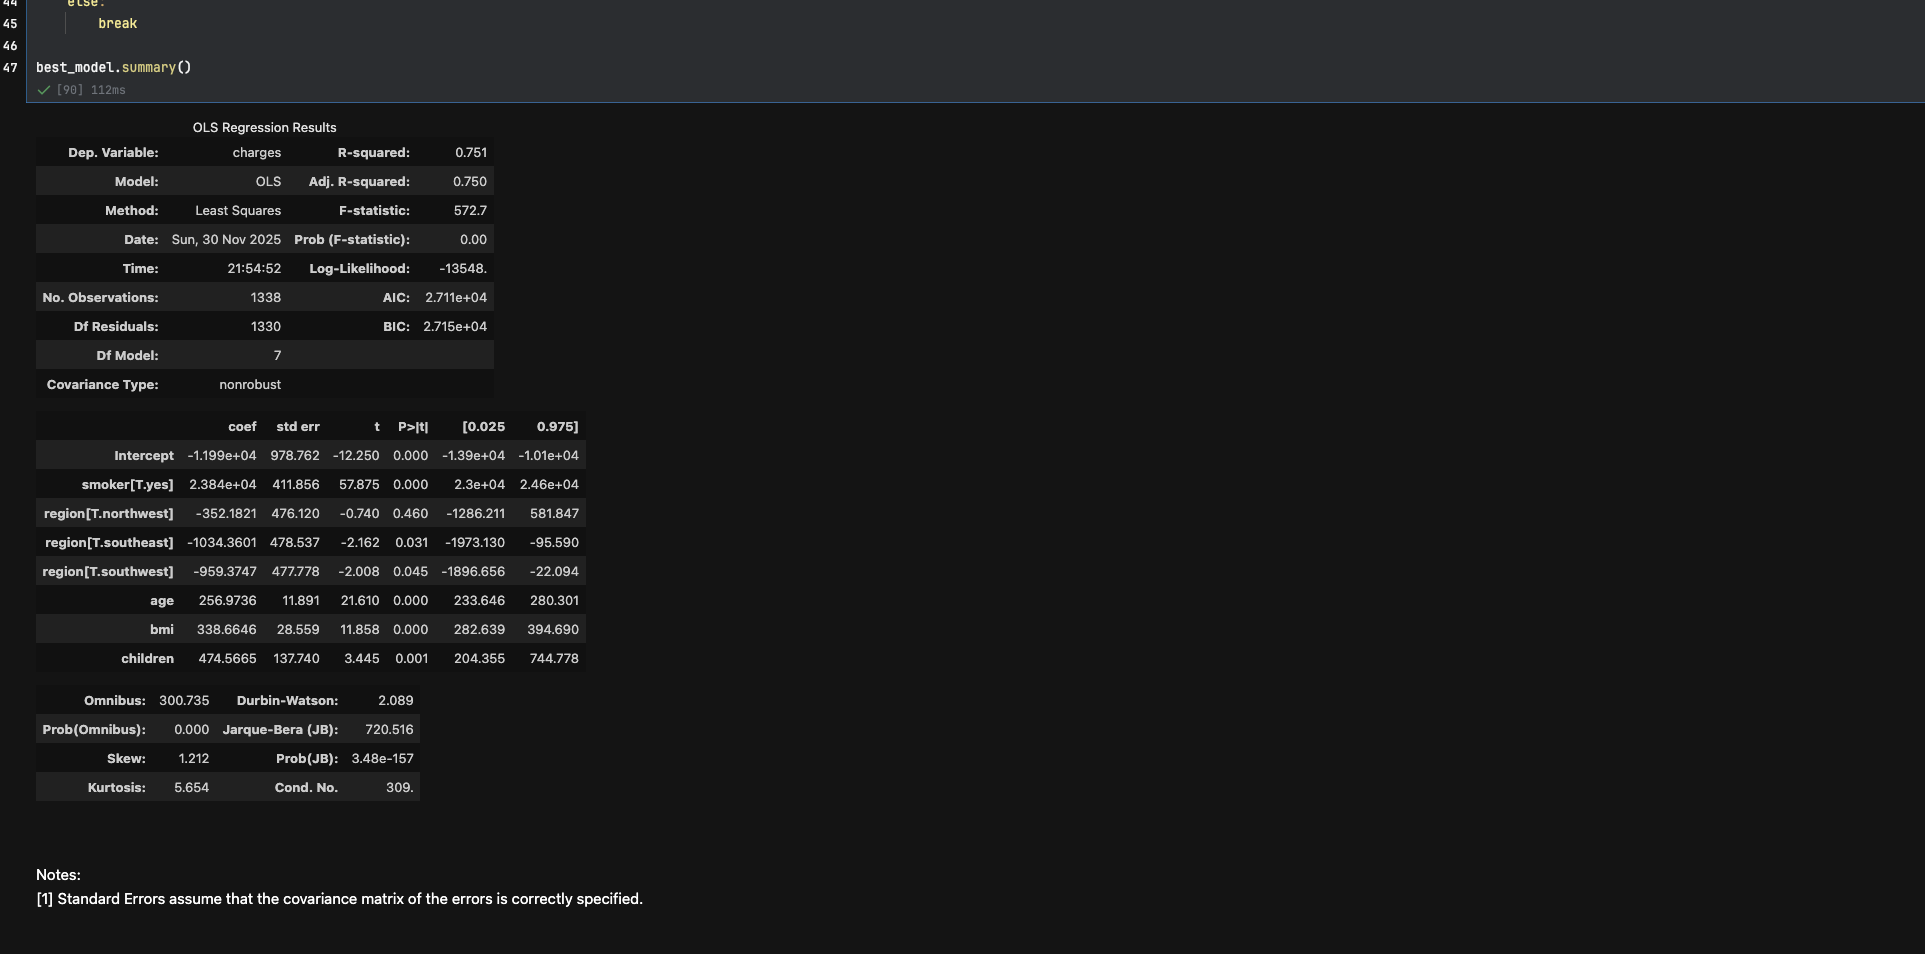

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

In [ ]:
%%sql


### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data.

In [16]:
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
filename = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

url = location + filename
cols = [
    "SampleCodeNumber",
    "UniformityCellSize",
    "UniformityCellShape",
    "SingleEpithelialCellSize",
     "MarginalAdhesion",
    "BareNuclei",
    "BlandChromatin",
   "ClumpThickness",
    "NormalNucleoli",
    "Mitoses",
    "Class"
]
df = pd.read_csv(url, names=cols, na_values="?")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SampleCodeNumber          699 non-null    int64  
 1   UniformityCellSize        699 non-null    int64  
 2   UniformityCellShape       699 non-null    int64  
 3   SingleEpithelialCellSize  699 non-null    int64  
 4   MarginalAdhesion          699 non-null    int64  
 5   BareNuclei                699 non-null    int64  
 6   BlandChromatin            683 non-null    float64
 7   ClumpThickness            699 non-null    int64  
 8   NormalNucleoli            699 non-null    int64  
 9   Mitoses                   699 non-null    int64  
 10  Class                     699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [17]:
df[df.isna().any(axis=1)]

,SampleCodeNumber,UniformityCellSize,UniformityCellShape,SingleEpithelialCellSize,MarginalAdhesion,BareNuclei,BlandChromatin,ClumpThickness,NormalNucleoli,Mitoses,Class
23,1057013,8,4,5,1,2,NaN,7,3,1,4
40,1096800,6,6,6,9,6,NaN,7,8,1,2
139,1183246,1,1,1,1,1,NaN,2,1,1,2
145,1184840,1,1,3,1,2,NaN,2,1,1,2
158,1193683,1,1,2,1,3,NaN,1,1,1,2
164,1197510,5,1,1,1,2,NaN,3,1,1,2
235,1241232,3,1,4,1,2,NaN,3,1,1,2
249,169356,3,1,1,1,2,NaN,3,1,1,2
275,432809,3,1,3,1,2,NaN,2,1,1,2
292,563649,8,8,8,1,2,NaN,6,10,1,4


There are a couple problems with this dataset. BlandChromatin is a float64 but the legend for the dataset indicates its an integer.
Also, the legend indicates BareNuclei is the column with NaN, but upon inspection it looks like BlandChromatin is the column
with missing data.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [18]:
def subset(dataset, perc):
    df = dataset.sample(frac=1)
    end = int(len(df) * perc)
    return (df[0:end], df[end:])

training, test = subset(df, 0.7)

In [23]:
training

,SampleCodeNumber,UniformityCellSize,UniformityCellShape,SingleEpithelialCellSize,MarginalAdhesion,BareNuclei,BlandChromatin,ClumpThickness,NormalNucleoli,Mitoses,Class
355,857774,4,1,1,1,3,1.0,2,2,1,2
560,1321942,5,1,1,1,2,1.0,3,1,1,2
456,1257470,10,6,5,8,5,10.0,8,6,1,4
271,411453,5,1,1,1,2,1.0,3,1,1,2
139,1183246,1,1,1,1,1,NaN,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
690,654546,1,1,1,3,2,1.0,1,1,1,2
71,1123061,6,10,2,8,10,2.0,7,8,10,4
268,324427,10,8,8,2,3,4.0,8,7,8,4
491,1119189,5,8,9,4,3,10.0,7,1,1,4


In [29]:
# Check if any rows in test are in training
merged = training.merge(test, how='inner')
print(f"Overlapping rows: {len(merged)}")

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, df.drop('Class', axis=1), df['Class'], cv=5, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

Overlapping rows: 4
Cross-validation scores: [0.92857143 0.94285714 0.97142857 0.97857143 0.98561151]
Mean CV accuracy: 0.96 ± 0.02


(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X_train = training
Y_train = training["Class"]
X_test = test
Y_test = test["Class"]

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, Y_train)

pred = model.predict(X_test)

print(accuracy_score(Y_test, pred) * 100)

matrix = confusion_matrix(Y_test, pred)
print("Confusion matrix")
print(matrix)

100.0
Confusion matrix
[[127   0]
 [  0  83]]


In [28]:
print("Training class distribution:")
print(Y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(Y_test.value_counts(normalize=True))

Training class distribution:
Class
2    0.676892
4    0.323108
Name: proportion, dtype: float64

Test class distribution:
Class
2    0.604762
4    0.395238
Name: proportion, dtype: float64


The resulting confusion matrix shows a 100% true prediction versus actual classification.
This is problematic because it's very unlikely the data is so highly correlated. Therefore,
it's possible this model has overfit the training data and is only coincidentally accurate.
Since this is using a machine learning model, it is more difficult to extract the terms
that directly correlate with the diagnosis.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer.

1) Classification could be used to predict whether a star has a planet. An inherently tricky calculation that is dependent upon a few observed values including redshift and magnitude of the light detected.
2) You can run classification on transactions to predict whether it is likely fradulent. This might leverage signals like location, price, and recent transaction count.
3) It can also be used to predict the presence of minerals in a potential dig site. Signals could include absorption bands (hsi imagery), vegetative health, and soil quality.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer.

Regression produces a continous output, therefore it is good for probabilities, confidence, and other similar questions.
1) Risk analysis for lending purposes. The predictors could be credit score, total debt to income ratio, total income, employment status. The result would be a probability indicating how likely the person would be to pay back a loan.
2) Battery life prediction. The predictors could be: total screen time, average time until charge cycle, total duration of charge cycle. The result would be an estimation of how much battery likely remains based on usage patterns.
3) "Server Compute" capacity planning. Given demand from customers, average cpu usage, trends in current resource allocation. We can predict how many more servers to buy to support potential demand increases.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

### A very flexible model can capture complex patterns and often predict better when you have lots of data, but it can easily overfit and is harder to interpret.
A less flexible model is more stable, easier to explain, and better when data are limited or noisy, but it may miss important nonlinear relationships.
Use more flexibility when you want pure prediction accuracy, while you can use less flexibility when you care about interpretability or have small/noisy data.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

Answer is: iii
Because females earn mroe at a lower GPA, but there is an intercept point once the GPA is high enough that flips the equation. Which leads to males earning more at higher GPA.

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

Salarly = 50 + 20 GPA + 0.07 IQ + 35 Gender + 0.01(GPA * IQ) - 10(GPA * Gender)



In [20]:
salary = 50+20*4+0.07*110+35+0.01*(4.0*110) - 10*(4.0 * 1)
print("Salary  =  $" + str(salary*1000))

Salary  =  $137100.0


(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

False.
A small interaction coefficient doesn’t equal the interaction effect is weak. More so, what matters is if the term is statistically significant. Whether its p-value is small relative to its standard error. If the p-value is large, then the interaction isn’t supported by the data, regardless of how big or small the coefficient looks.


### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  